# 🍎 Deteksi Kesegaran Buah dengan *Classical Computer Vision* + SVM

**AoL Computer Vision — Kelompok 4**  
Fransiscus Owen Ladjuardi · Christian · Michael Peterson · Nicholas Lee

---

Notebook ini mendemokan **pipeline koding** sistem klasifikasi buah **fresh vs rotten**. Berbeda dari pendekatan *deep learning* yang berat dan *black box*, kami memakai **fitur klasik yang terukur** (warna + tekstur) lalu mengklasifikasi dengan **SVM**.

**Alur pipeline:**

| Tahap | Teknik |
|---|---|
| 1. Preprocessing | Resize 128×128 → Gaussian Blur → CLAHE |
| 2. Segmentasi | HSV Threshold → Morphology → Kontur terbesar |
| 3. Fitur Warna | Histogram HSV 8×8×8 (512) + Mean HSV (3) |
| 4. Fitur Tekstur | ORB descriptor mean (32) |
| 5. Klasifikasi | StandardScaler → SVM (RBF) → export ONNX |

Total **547 fitur** per gambar.

# 1. Import Library

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# untuk export model ke ONNX (dipakai di backend / aplikasi Flutter)
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

np.random.seed(42)
print('Library siap.')

Library siap.


# 2. Konfigurasi & Path Dataset

Dataset: [Fruits Fresh and Rotten for Classification](https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification) (apel, pisang, jeruk — masing-masing *fresh* & *rotten*).

> Ubah `DATA_DIR` sesuai lingkungan: path **Kaggle** sudah jadi default, tinggal di-*comment/uncomment* untuk Colab atau lokal.

In [2]:
# === Pilih salah satu sesuai lingkungan ===
DATA_DIR = '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset'   # Kaggle
# DATA_DIR = '/content/dataset'        # Google Colab (setelah unzip)
# DATA_DIR = 'model2.2/dataset'        # Lokal

TRAIN_PATH = os.path.join(DATA_DIR, 'train')
TEST_PATH  = os.path.join(DATA_DIR, 'test')

IMG_SIZE = 128                 # semua gambar diseragamkan ke 128x128
CLASSES = ['fresh', 'rotten']  # klasifikasi BINER
MAX_KEYPOINTS = 100            # jumlah keypoint maksimum ORB
MIN_MASK_RATIO = 0.30          # ambang minimum luas mask segmentasi

print('Konfigurasi siap. Target kelas:', CLASSES)

Konfigurasi siap. Target kelas: ['fresh', 'rotten']


# 3. Eksplorasi Dataset

Dataset terdiri dari 6 folder (3 jenis buah × 2 kondisi). Label ditentukan otomatis dari nama folder: mengandung kata *fresh* → **0**, *rotten* → **1**.

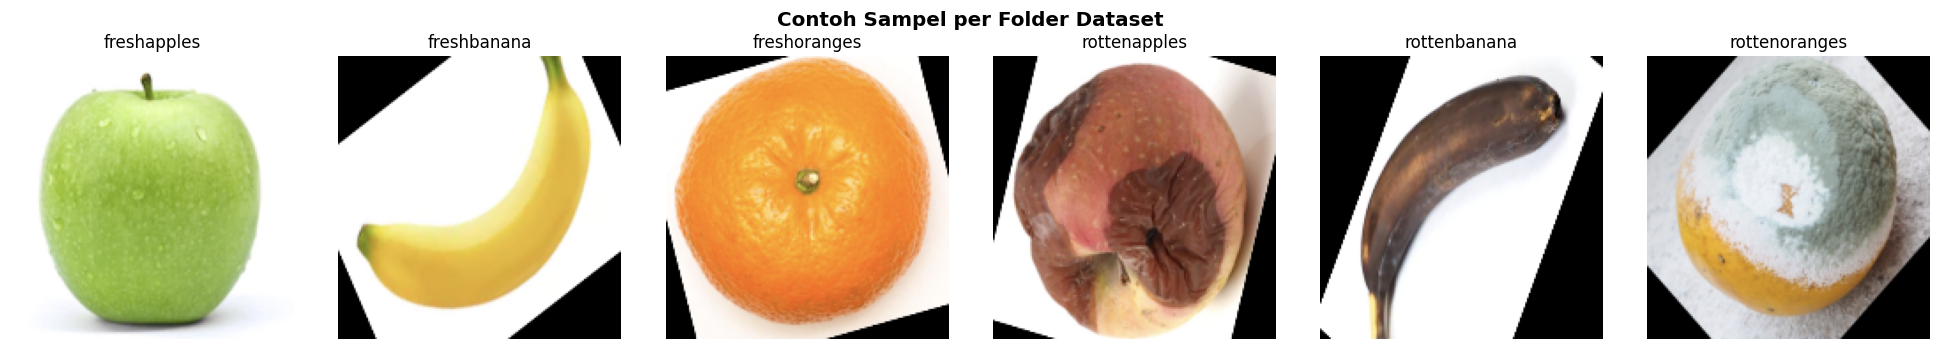

In [3]:
def get_label(folder_name):
    f = folder_name.lower()
    if 'fresh' in f:  return 0
    if 'rotten' in f: return 1
    return None

# tampilkan 1 contoh acak dari tiap folder
folders = sorted(os.listdir(TRAIN_PATH))
fig, axes = plt.subplots(1, len(folders), figsize=(3*len(folders), 3.2))
for ax, folder in zip(axes, folders):
    fp = os.path.join(TRAIN_PATH, folder)
    f = np.random.choice(os.listdir(fp))
    im = cv2.resize(cv2.imread(os.path.join(fp, f)), (160, 160))
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(folder); ax.axis('off')
plt.suptitle('Contoh Sampel per Folder Dataset', fontweight='bold')
plt.tight_layout(); plt.show()

Cek **distribusi data** — penting untuk tahu apakah kelas seimbang.

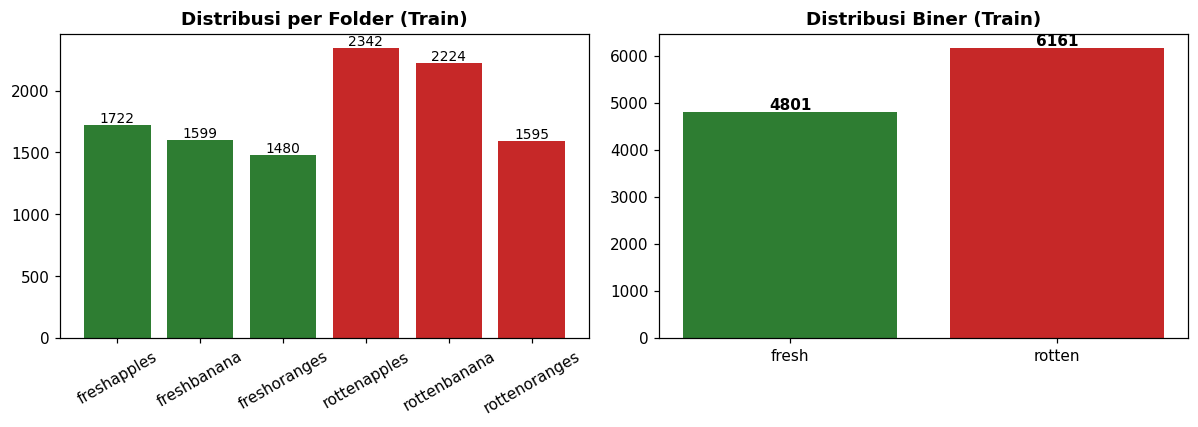

Total train: 10962  |  fresh=4801  rotten=6161


In [4]:
counts = {f: len(os.listdir(os.path.join(TRAIN_PATH, f))) for f in folders}
fresh_n  = sum(v for f, v in counts.items() if 'fresh' in f)
rotten_n = sum(v for f, v in counts.items() if 'rotten' in f)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(list(counts), list(counts.values()),
          color=['#2e7d32' if 'fresh' in f else '#c62828' for f in counts])
ax[0].set_title('Distribusi per Folder (Train)', fontweight='bold'); ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(['fresh', 'rotten'], [fresh_n, rotten_n], color=['#2e7d32', '#c62828'])
ax[1].set_title('Distribusi Biner (Train)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Total train: {sum(counts.values())}  |  fresh={fresh_n}  rotten={rotten_n}')

# 4. Preprocessing & Segmentasi

**Preprocessing** menyeragamkan & memperjelas gambar:
- **Resize 128×128** — ukuran seragam untuk semua gambar.
- **Gaussian Blur** — meredam *noise* kamera.
- **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) pada channel-L (ruang LAB) — menyamakan pencahayaan agar warna lebih konsisten.

**Segmentasi** memisahkan buah dari latar belakang dengan *thresholding* HSV + deteksi kontur, sehingga fitur hanya dihitung dari **piksel buah** (bukan background).

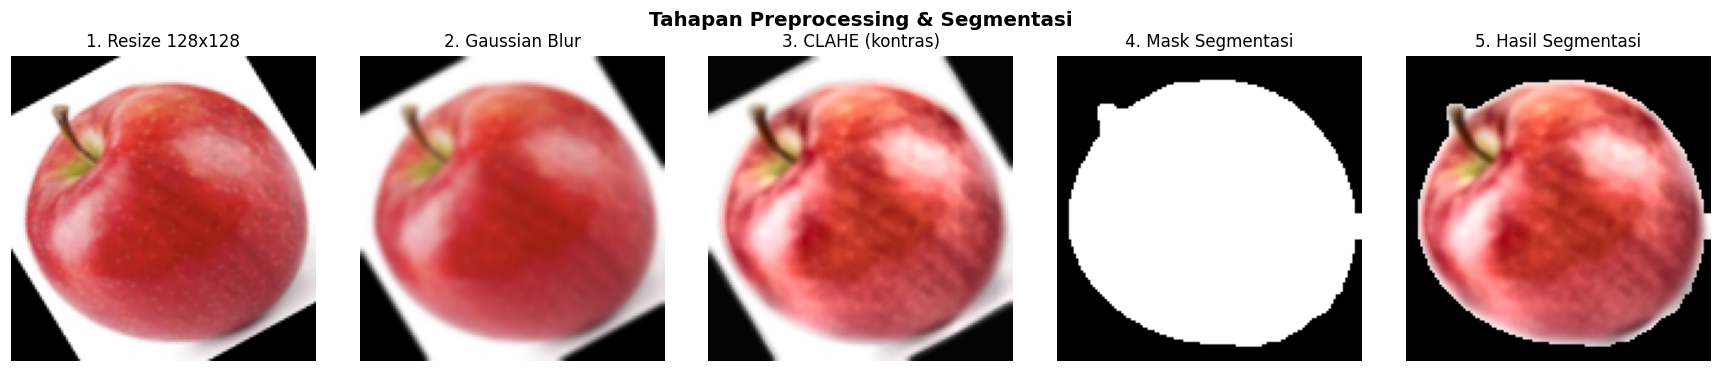

In [5]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.GaussianBlur(img, (5, 5), 0)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = cv2.merge((clahe.apply(l), a, b))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

def _center_crop_mask(shape):
    h, w = shape[:2]; mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (w//2, h//2), int(min(h, w)*0.40), 255, -1)
    return mask

def segment_fruit(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([0, 15, 15]), np.array([180, 255, 255]))
    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    fruit_mask = None
    if cnts:
        largest = max(cnts, key=cv2.contourArea)
        fruit_mask = np.zeros_like(mask)
        cv2.drawContours(fruit_mask, [largest], -1, 255, -1)
    # fallback: kalau mask kekecilan, pakai lingkaran tengah
    if fruit_mask is None or (fruit_mask > 0).sum()/fruit_mask.size < MIN_MASK_RATIO:
        fruit_mask = _center_crop_mask(img.shape)
    return cv2.bitwise_and(img, img, mask=fruit_mask), fruit_mask

# --- visualisasi tahapan pada 1 sampel ---
sample = os.path.join(TRAIN_PATH, 'freshapples',
                      np.random.choice(os.listdir(os.path.join(TRAIN_PATH, 'freshapples'))))
pre = preprocess_image(sample)
seg, mask = segment_fruit(pre)
raw = cv2.resize(cv2.imread(sample), (IMG_SIZE, IMG_SIZE))
stages = [(raw,'1. Resize'), (cv2.GaussianBlur(raw,(5,5),0),'2. Blur'),
          (pre,'3. CLAHE'), (cv2.cvtColor(mask,cv2.COLOR_GRAY2BGR),'4. Mask'), (seg,'5. Segmentasi')]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax,(im,t) in zip(axes, stages):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis('off')
plt.suptitle('Tahapan Preprocessing & Segmentasi', fontweight='bold')
plt.tight_layout(); plt.show()

# 5. Fitur Warna — Histogram HSV

Kesegaran buah sangat tercermin dari **warna** (buah busuk → kecokelatan/menggelap). Kami pakai ruang warna **HSV** karena lebih tahan terhadap perubahan pencahayaan daripada RGB.

- **Histogram HSV 8×8×8 = 512 nilai** → distribusi warna buah.
- **Mean HSV = 3 nilai** → warna rata-rata.

Semua dihitung **hanya di area mask** (piksel buah).

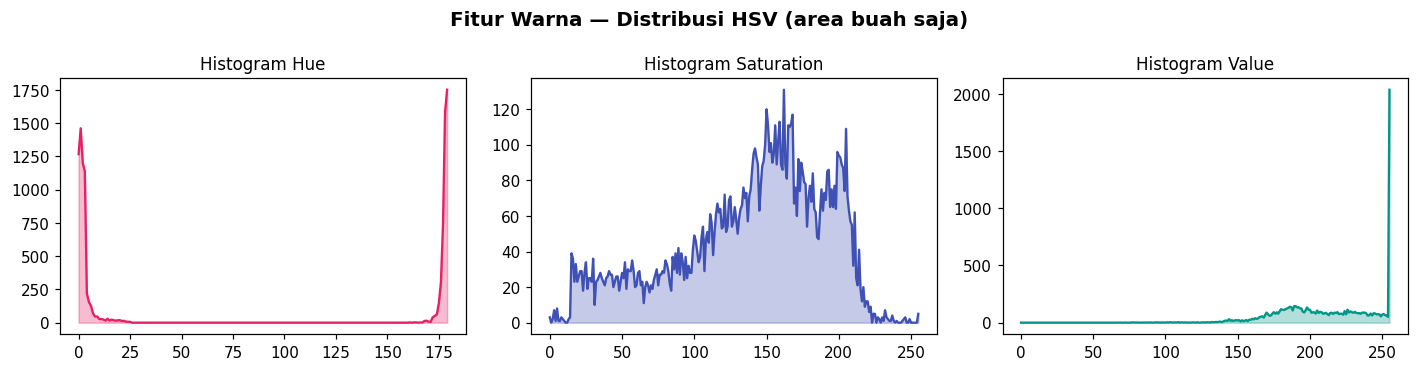

Dimensi fitur warna: 515


In [6]:
def extract_color_features(img, mask=None):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()        # 512
    mean_hsv = cv2.mean(hsv, mask=mask)[:3]            # 3
    return np.hstack([hist, mean_hsv])

# visualisasi distribusi tiap channel HSV pada area buah
hsv = cv2.cvtColor(seg, cv2.COLOR_BGR2HSV)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for i,(nm,rg,c) in enumerate([('Hue',180,'#e91e63'),('Saturation',256,'#3f51b5'),('Value',256,'#009688')]):
    h = cv2.calcHist([hsv],[i],mask,[rg],[0,rg])
    ax[i].fill_between(range(len(h)), h.flatten(), alpha=.4, color=c); ax[i].set_title(f'Histogram {nm}')
plt.suptitle('Fitur Warna — Distribusi HSV (area buah saja)', fontweight='bold')
plt.tight_layout(); plt.show()
print('Dimensi fitur warna:', extract_color_features(seg, mask).shape[0])

# 6. Fitur Tekstur — ORB

Selain warna, **tekstur permukaan** membedakan buah segar (mulus) vs busuk (berkerut/berbintik). **ORB** (*Oriented FAST and Rotated BRIEF*) mendeteksi *keypoint* tekstur lalu menghasilkan *descriptor*. Kami ambil **rata-rata descriptor = 32 nilai** sebagai ringkasan tekstur.

> Titik merah = keypoint tekstur yang terdeteksi ORB.

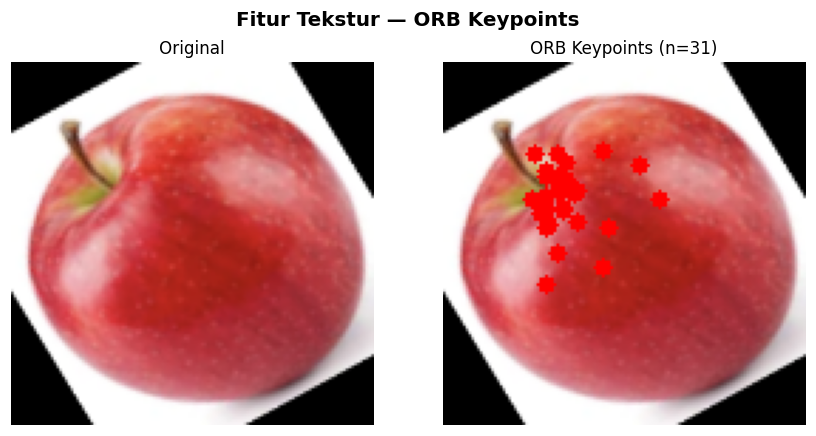

In [7]:
def extract_orb_features(img, mask=None):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=MAX_KEYPOINTS)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        return np.zeros(32), keypoints
    return descriptors.mean(axis=0), keypoints      # 32

_, kps = extract_orb_features(seg, mask)
kp_img = raw.copy()
for k in kps:
    cv2.circle(kp_img, (int(k.pt[0]), int(k.pt[1])), 3, (0, 0, 255), -1)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(kp_img, cv2.COLOR_BGR2RGB)); ax[1].set_title(f'ORB Keypoints (n={len(kps)})'); ax[1].axis('off')
plt.suptitle('Fitur Tekstur — ORB Keypoints', fontweight='bold')
plt.tight_layout(); plt.show()

# 7. Gabungan Fitur — Vektor 547 Dimensi

Fitur warna dan tekstur digabung menjadi **satu vektor fitur** per gambar:

$$\\text{fitur} = \\underbrace{[\\text{Hist HSV}]}_{512} + \\underbrace{[\\text{Mean HSV}]}_{3} + \\underbrace{[\\text{ORB mean}]}_{32} = 547$$

In [8]:
def extract_features(image_path):
    img = preprocess_image(image_path)
    segmented, mask = segment_fruit(img)
    color = extract_color_features(segmented, mask)
    orb, _ = extract_orb_features(segmented, mask)
    return np.hstack([color, orb])

v = extract_features(sample)
print('Panjang vektor fitur:', v.shape[0])

Panjang vektor fitur: 547


# 8. Augmentasi Data

Agar model **tahan terhadap kondisi kamera HP nyata** (pencahayaan, sudut, noise), setiap gambar *training* diperbanyak menjadi 7 variasi: brightness, hue/saturation jitter, color-temperature, rotasi ±15°, flip, Gaussian noise, dan contrast. Dataset training membengkak **~8×**.

> Augmentasi hanya untuk **training**, tidak untuk data test.

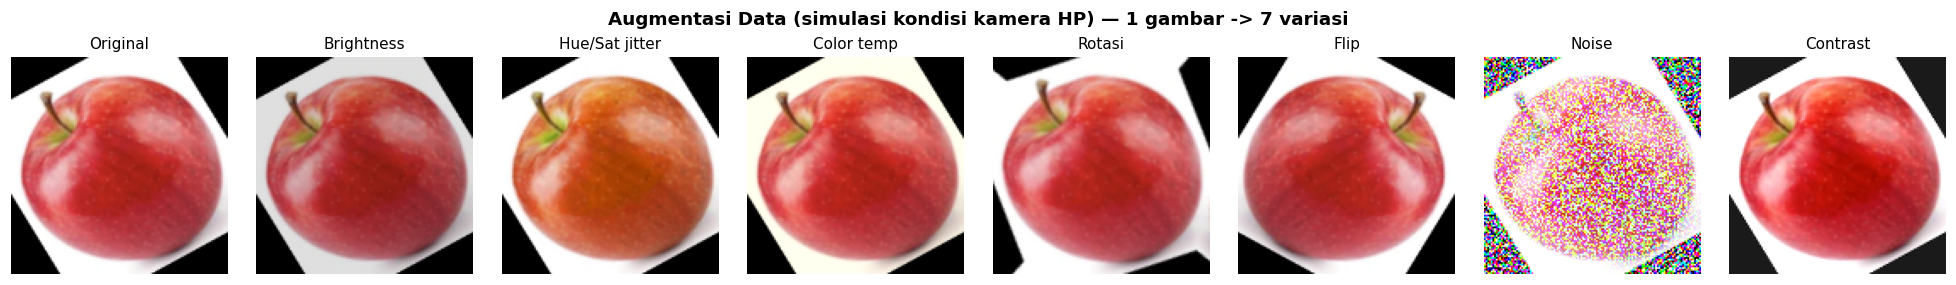

In [9]:
def augment_image(img):
    h, w = img.shape[:2]; out = []
    out.append(cv2.convertScaleAbs(img, alpha=np.random.uniform(0.5, 1.5)))            # brightness
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + np.random.uniform(-10, 10)) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * np.random.uniform(0.7, 1.3), 0, 255)
    out.append(cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR))                   # hue/sat
    t = img.copy().astype(np.float32); t[:,:,0]*=np.random.uniform(0.85,1.0); t[:,:,2]*=np.random.uniform(1.0,1.15)
    out.append(np.clip(t, 0, 255).astype(np.uint8))                                    # color temp
    M = cv2.getRotationMatrix2D((w//2, h//2), np.random.uniform(-15, 15), 1.0)
    out.append(cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT))          # rotasi
    out.append(cv2.flip(img, 1))                                                       # flip
    out.append(cv2.add(img, np.random.normal(0, 15, img.shape).astype(np.uint8)))      # noise
    c = np.random.uniform(0.7, 1.3)
    out.append(cv2.convertScaleAbs(img, alpha=c, beta=img.mean()*(1-c)))               # contrast
    return out

augs = augment_image(raw)
titles = ['Brightness','Hue/Sat','Color temp','Rotasi','Flip','Noise','Contrast']
fig, axes = plt.subplots(1, 8, figsize=(18, 2.6))
axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
for ax, t, im in zip(axes[1:], titles, augs):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis('off')
plt.suptitle('Augmentasi Data — 1 gambar menjadi 7 variasi', fontweight='bold')
plt.tight_layout(); plt.show()

# 9. Memuat Dataset (Ekstraksi Fitur)

Semua gambar diubah menjadi vektor fitur. Data **train** memakai augmentasi (×8), data **test** tidak.

> ⏱️ Sel ini berat (mengekstrak fitur dari puluhan ribu gambar) — butuh beberapa menit di Kaggle.

In [10]:
def preprocess_img_direct(img):
    img = cv2.GaussianBlur(img, (5, 5), 0)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB); l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

def extract_features_from_img(img):
    seg, mask = segment_fruit(img)
    return np.hstack([extract_color_features(seg, mask), extract_orb_features(seg, mask)[0]])

def load_dataset(base_path, augment=False):
    X, y = [], []
    for folder in os.listdir(base_path):
        fp = os.path.join(base_path, folder)
        if not os.path.isdir(fp): continue
        label = get_label(folder)
        if label is None: continue
        print('Loading folder:', folder)
        for file in os.listdir(fp):
            path = os.path.join(fp, file)
            try:
                X.append(extract_features(path)); y.append(label)
                if augment:
                    img = cv2.resize(cv2.imread(path), (IMG_SIZE, IMG_SIZE))
                    for aug in augment_image(img):
                        try:
                            X.append(extract_features_from_img(preprocess_img_direct(aug))); y.append(label)
                        except: pass
            except: pass
    return np.array(X), np.array(y)

print('Loading TRAIN (dengan augmentasi)...')
X_train, y_train = load_dataset(TRAIN_PATH, augment=True)
print('Loading TEST (tanpa augmentasi)...')
X_test, y_test = load_dataset(TEST_PATH, augment=False)
print('\nTrain size:', len(X_train), '| Test size:', len(X_test))

Loading TRAIN (dengan augmentasi)...
Loading folder: freshapples
Loading folder: freshbanana
Loading folder: freshoranges
Loading folder: rottenapples
Loading folder: rottenbanana
Loading folder: rottenoranges
Loading TEST (tanpa augmentasi)...
Loading folder: freshapples
Loading folder: freshbanana
Loading folder: freshoranges
Loading folder: rottenapples
Loading folder: rottenbanana
Loading folder: rottenoranges

Train size: 87696 | Test size: 2698


# 10. Feature Scaling + Training SVM

Fitur dinormalisasi dengan **StandardScaler** (agar tiap fitur setara skalanya), lalu diklasifikasi dengan **SVM kernel RBF** (`C=10`). SVM dipilih karena tangguh pada ruang fitur berdimensi tinggi (547) dengan jumlah data menengah.

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
model.fit(X_train_s, y_train)
print('Training SVM selesai.')

Training SVM selesai.


# 11. Simpan Model & Export ke ONNX

Scaler + SVM digabung jadi **satu Pipeline** lalu di-export ke **ONNX**. Format ONNX inilah yang dipakai **backend (FastAPI)** dan aplikasi **Flutter** untuk inferensi — tanpa perlu scikit-learn.

In [12]:
joblib.dump(model, 'model_svm.pkl')
joblib.dump(scaler, 'scaler.pkl')

pipeline = Pipeline([('scaler', scaler), ('svm', model)])
initial_type = [('input', FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_sklearn(pipeline, initial_types=initial_type)
with open('fruit_model.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())
print('Model tersimpan: model_svm.pkl, scaler.pkl, fruit_model.onnx')

Model tersimpan: model_svm.pkl, scaler.pkl, fruit_model.onnx


# 12. Evaluasi Model 📊

Evaluasi pada **2.698 gambar test** (tidak diaugmentasi, tidak pernah dilihat saat training). Metrik: accuracy, precision, recall, f1-score, dan confusion matrix.

> Output di bawah adalah **hasil nyata** dari model yang dipakai aplikasi (`fruit_model.onnx`).

In [13]:
y_pred = model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

Accuracy: 0.9848 (98.48%)

Classification Report:
              precision    recall  f1-score   support

       fresh       0.99      0.98      0.98      1164
      rotten       0.98      0.99      0.99      1534

    accuracy                           0.98      2698
   macro avg       0.98      0.98      0.98      2698
weighted avg       0.98      0.98      0.98      2698


**Confusion Matrix** — memvisualisasikan benar/salah per kelas.

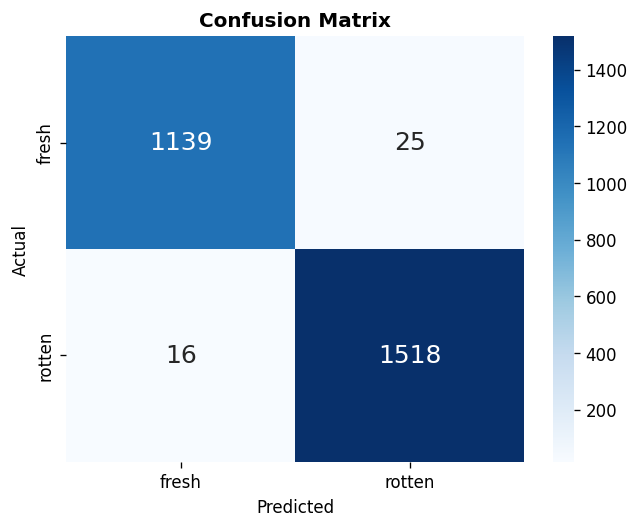

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 15})
plt.title('Confusion Matrix', fontweight='bold'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

**Akurasi per kelas** — apakah model bias ke salah satu kelas?

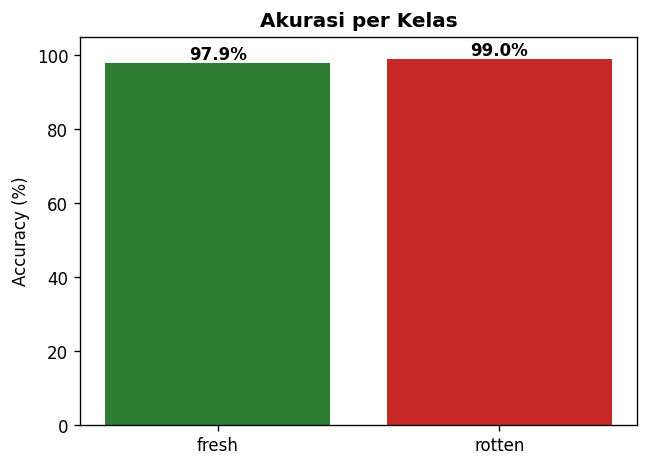

In [15]:
per_class = cm.diagonal() / cm.sum(axis=1)
bars = plt.bar(CLASSES, per_class*100, color=['#2e7d32', '#c62828']); plt.ylim(0, 105)
plt.title('Akurasi per Kelas', fontweight='bold'); plt.ylabel('Accuracy (%)')
for b, v in zip(bars, per_class):
    plt.text(b.get_x()+b.get_width()/2, v*100+1, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

# 13. Contoh Prediksi pada Data Test

Uji visual: judul **hijau** = prediksi benar, **merah** = salah.

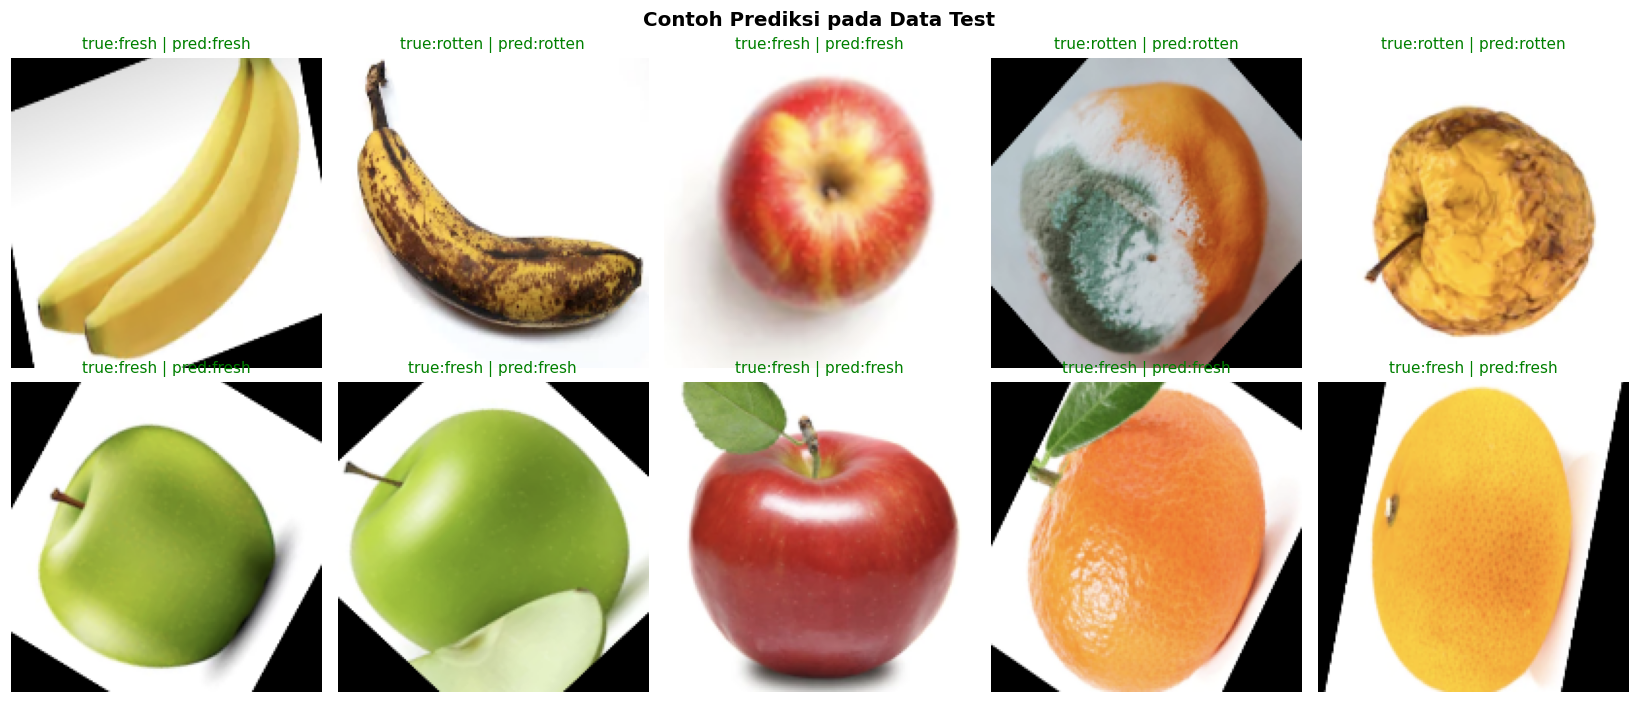

In [16]:
import random
samples = []
for folder in os.listdir(TEST_PATH):
    fp = os.path.join(TEST_PATH, folder); lab = get_label(folder)
    if lab is None: continue
    for f in random.sample(os.listdir(fp), 2):
        samples.append((os.path.join(fp, f), lab))
random.shuffle(samples); samples = samples[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5)); axes = axes.flatten()
for ax, (path, lab) in zip(axes, samples):
    feat = scaler.transform([extract_features(path)])
    pred = model.predict(feat)[0]
    im = cv2.resize(cv2.imread(path), (160, 160))
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f'true:{CLASSES[lab]} | pred:{CLASSES[pred]}',
                 color='green' if pred == lab else 'red', fontsize=10); ax.axis('off')
plt.suptitle('Contoh Prediksi pada Data Test', fontweight='bold')
plt.tight_layout(); plt.show()

# 14. Kesimpulan

- Pipeline **classical computer vision + SVM** mencapai **akurasi 98.48%** pada 2.698 gambar test — kompetitif dengan deep learning, namun **jauh lebih ringan & transparan**.
- Fitur **warna (HSV)** + **tekstur (ORB)** terbukti cukup membedakan buah *fresh* vs *rotten*.
- **Augmentasi** membuat model tahan terhadap variasi kondisi kamera HP.
- Model di-export ke **ONNX** → dipakai backend **FastAPI** & aplikasi **Flutter** secara nyata.

**Pengembangan lanjut:** deploy model ke cloud (saat ini masih lokal), dan menambah kelas tingkat kesegaran (mis. *ripe*) bila tersedia datanya.